In [2]:
import pandas as pd
import numpy as np
# Important: fit_transform() is not a method of LogisticRegression(). 
#     It is commonly used with data preprocessing tools such as StandardScaler, OneHotEncoder, and PCA.
df = pd.read_csv("placement.csv")
print(df)

     cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
995  8.87                  44.0       1
996  9.12                  65.0       1
997  4.89                  34.0       0
998  8.62                  46.0       1
999  4.90                  10.0       1

[1000 rows x 3 columns]


In [6]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


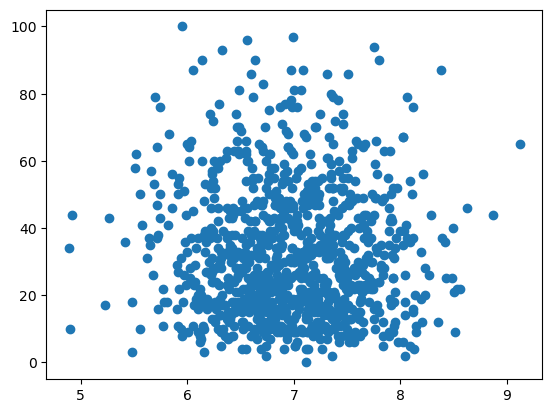

In [9]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['placement_exam_marks']) #x, y axis

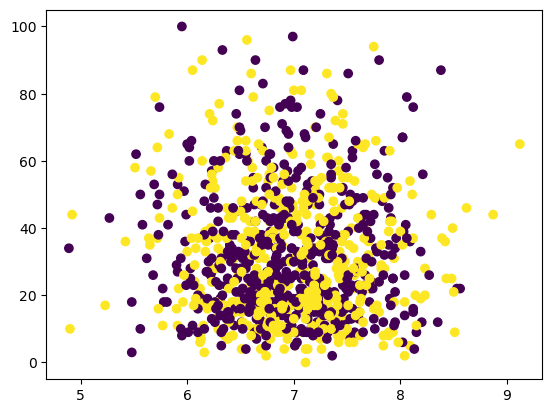

In [10]:
plt.scatter(df['cgpa'], df['placement_exam_marks'], c=df['placed'])

In [23]:
from sklearn.model_selection import train_test_split
# X = df[0:1] # it gives rows from 0th row excluding 
# Y = df[2:]  # it also rows from 2 to end
# print(X)
# print(Y)

# if you want the columns either manually specify or use iloc has 
# iloc[rows, columns] - if we skip specify columns it takes the alll rows of all columns by default
# iloc[:, 0:2] # takes all rows of 0 and 1 columns

X =  df[['cgpa', 'placement_exam_marks']] # df is data frame - inside it select 2 columns using the array
Y = df[['placed']] # selects the target column
print(X)
print(Y)


     cgpa  placement_exam_marks
0    7.19                  26.0
1    7.46                  38.0
2    7.54                  40.0
3    6.42                   8.0
4    7.23                  17.0
..    ...                   ...
995  8.87                  44.0
996  9.12                  65.0
997  4.89                  34.0
998  8.62                  46.0
999  4.90                  10.0

[1000 rows x 2 columns]
     placed
0         1
1         1
2         1
3         1
4         0
..      ...
995       1
996       1
997       0
998       1
999       1

[1000 rows x 1 columns]


In [46]:
X_input_train, X_input_test, Y_output_train, Y_output_test = train_test_split(X, Y, test_size=0.1)
print(X_input_train) # train samples of input columns
print(X_input_test) # test samples of input column

     cgpa  placement_exam_marks
44   7.88                  55.0
498  6.89                  14.0
577  6.85                  24.0
400  6.00                  33.0
758  6.55                  29.0
..    ...                   ...
723  7.35                  10.0
930  6.94                   7.0
119  7.00                  39.0
405  6.60                  32.0
290  8.38                  87.0

[900 rows x 2 columns]
     cgpa  placement_exam_marks
645  6.75                  36.0
110  6.96                  31.0
969  6.86                  41.0
945  6.71                  26.0
24   6.44                  11.0
..    ...                   ...
711  6.97                  30.0
342  6.37                  23.0
458  7.13                  47.0
848  7.20                  27.0
91   7.42                   6.0

[100 rows x 2 columns]


In [47]:
# # before training the model - we need to bring all of these values to one range
# # by using standard scalar we can bring them int one range -3 to +3
# # so that - result won't be biased towards bigger values of marks while cgpa being ignored
#  StandardScaler converts values into standardized values. this is preporcessing step

# fit_transform()
#       |
#       ├── fit()
#       |     Learn information from X - calculates mean, standard_deviation
#       |
#       └── transform()
#             Use learned information to convert X and then it converts these inputs and outputs into learned values. check below example

# 2. Then what is fit_transform()?
# To understand this, first understand transform().

# Imagine you have raw data:

# X = [[10], [20], [30], [40], [50]]

# These are study hours, salary, age, or some other numerical features.

# A preprocessing tool may need to convert the data into a different format before giving it to a model.

# For example, StandardScaler converts values into standardized values.

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)

# Here:

# fit_transform()
#       |
#       ├── fit()
#       |     Learn information from X
#       |
#       └── transform()
#             Use learned information to convert X

# So:

# fit_transform() = First learn from the data, then transform that same data.

# 3. Understand with a real example
# Step 1: Raw data
# X = [[10], [20], [30], [40], [50]]

# Think of these as five students' study hours.

# Step 2: Create the scaler
# scaler = StandardScaler()

# At this moment:

# scaler = Empty preprocessing object

# It has not learned the mean or standard deviation of your data yet.

# Step 3: Call fit_transform()
# X_scaled = scaler.fit_transform(X)

# This performs two operations.

# Operation A: fit(X)

# The scaler calculates statistics from the data.

# Mean:

# μ=
# 5
# 10+20+30+40+50
# 	​

# =30

# Standard deviation:

# σ≈14.14

# The scaler stores these values internally.

# Conceptually:

# scaler.mean_
# # [30.]

# scaler.scale_
# # [14.142...]

# Now it knows:

# Mean = 30
# Standard deviation ≈ 14.14
# Operation B: transform(X)

# The scaler uses the learned mean and standard deviation to convert every value.

# Formula:

# z=
# σ
# x−μ
# 	​


# For 10:

# z=
# 14.14
# 10−30
# 	​

# ≈−1.41

# For 30:

# z=
# 14.14
# 30−30
# 	​

# =0

# For 50:

# z=
# 14.14
# 50−30
# 	​

# ≈1.41

# Result:

# X_scaled

# Approximately:

# [
#  [-1.41],
#  [-0.71],
#  [ 0.00],
#  [ 0.71],
#  [ 1.41]
# ]
# In Tenglish

# fit_transform() ante:

# First data ni observe chesi required information nerchukuntundi (fit). Tarvatha aa nerchukunna information use chesi data ni convert chestundi (transform).

In [48]:
#1.  Raw input

# X
# Study hours
# 10, 20, 30, 40, 50

# StandardScaler.fit_transform(X)
# Learn mean and standard deviation → Convert values

# 2. Transformed input
# X_scaled

# Standardized numbers

# -1.41, -0.71, 0, 0.71, 1.41

# LogisticRegression.fit(X_scaled, y)

# Learn weights and bias for classification

# Prediction

# Pass / Fail

# Example: Study 35 hours

# Key point: fit_transform() belongs to the scaler. model.fit() belongs to Logistic Regression.

In [53]:
# convert the X_train and X_test to the standard scalar

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(X_input_train)
X_input_train = scaler.fit_transform(X_input_train)
X_input_test = scaler.transform(X_input_test)

print(dir(X_input_train)) # all the values in the range +3 to -3
print(X_input_train.size)

print(X_input_test)
print(X_input_test.size)

[[ 1.45009238  1.19053842]
 [-0.12469257 -0.95243074]
 [-0.18832024 -0.42975533]
 ...
 [ 0.05028354  0.35425777]
 [-0.58599321 -0.01161501]
 [ 2.24543831  2.86309972]]
['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__',

In [32]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

print(clf)

LogisticRegression()


In [33]:
print(clf.get_params()) # class_weight': None

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [34]:
print(dir(clf)) # to see what are all the functions does it have

['C', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_params_html', '_html_repr', '_parameter_constraints', '_predict_proba_lr', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_params', 'class_weight', 'decision_function', 'densify', 'dual', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'intercept_scaling', 'l1_r

In [35]:
print(type(clf))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [56]:
## when the model is not learned - the output may look likes the weight and bias 
clf.fit(X_input_train, Y_output_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
# Get learned weight and bias
w = clf.coef_[0][0]
b = clf.intercept_[0]
print(w)
print(b)

0.054772438407286565
-0.057890594978593855


In [59]:
"""
Yes — the model stores the learned parameters, but usually it does not store the formula as a ready-made string.

The formula is fixed by the Logistic Regression algorithm:

p=1/1+e−(wx+b)


After training, the model stores only the values learned from your data:

clf.coef_       # learned weight(s)
clf.intercept_  # learned bias

For example:

print(clf.coef_)
print(clf.intercept_)

Output might look like:

[[2.35]]
[-0.82]

The model conceptually represents:

p=1/1+e−((2.35x)−0.82)

	​

But sklearn does not generally store this as text like:

"p = 1 / (1 + exp(-(2.35*x - 0.82)))"
Why?

Because the model needs to calculate predictions, not display a human-readable equation.

When you call:

clf.predict_proba(X)

sklearn internally does something conceptually equivalent to:

z = X @ clf.coef_.T + clf.intercept_
probability = 1 / (1 + np.exp(-z))

So the formula is already implemented inside the model's prediction logic.

You can use the model directly

You do not need to construct the formula yourself for prediction:

probability = clf.predict_proba(X_input_test) # it uses the formula and finds out

or:

prediction = clf.predict(X_input_test)

The model automatically uses its stored weights and bias.

"""

'\nYes — the model stores the learned parameters, but usually it does not store the formula as a ready-made string.\n\nThe formula is fixed by the Logistic Regression algorithm:\n\np=\n1+e\n−(wx+b)\n1\n\t\u200b\n\n\nAfter training, the model stores only the values learned from your data:\n\nclf.coef_       # learned weight(s)\nclf.intercept_  # learned bias\n\nFor example:\n\nprint(clf.coef_)\nprint(clf.intercept_)\n\nOutput might look like:\n\n[[2.35]]\n[-0.82]\n\nThe model conceptually represents:\n\np=\n1+e\n−((2.35x)−0.82)\n1\n\t\u200b\n\n\nBut sklearn does not generally store this as text like:\n\n"p = 1 / (1 + exp(-(2.35*x - 0.82)))"\nWhy?\n\nBecause the model needs to calculate predictions, not display a human-readable equation.\n\nWhen you call:\n\nclf.predict_proba(X)\n\nsklearn internally does something conceptually equivalent to:\n\nz = X @ clf.coef_.T + clf.intercept_\nprobability = 1 / (1 + np.exp(-z))\n\nSo the formula is already implemented inside the model\'s prediction

In [63]:
Predicted_output = clf.predict(X_input_test)

In [65]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_output_test, Predicted_output)

0.47

In [67]:
# accuracy_score is 47% - means model is not performing well.
# calculate the decision boundary it made
%pip install mlxtend


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 9.3 MB/s  0:00:01m 9.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 8.8 MB/s  0:00:008.9 MB/s eta 0:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.6 0/3 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]━━━ 1/3 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


ImportError: cannot import name 'decision_boundary_regions' from 'mlxtend.plotting' (/opt/anaconda3/lib/python3.13/site-packages/mlxtend/plotting/__init__.py)

<Axes: >

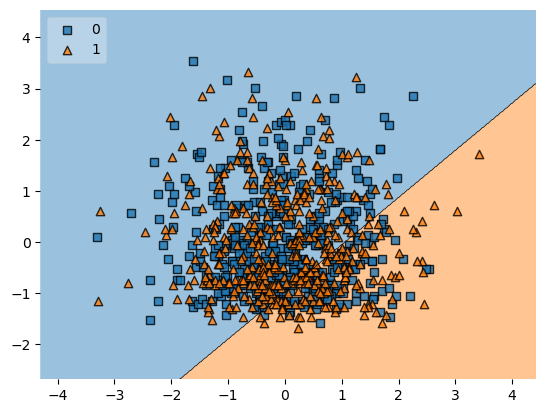

In [76]:
from mlxtend.plotting import plot_decision_regions
# plot_decision_regions(X_input_train, Y_output_train, clf=clf, legend=2)
# StandardScaler.fit_transform() returns a NumPy array
# for Y_output_train - we need to convert to manually
# either we can take - Y_output_train.values() or Y_output_train.to_numpy()
# plot_decision_regions(X_input_train, Y_output_train.values, clf=clf, legend=2)

Y_output_train = Y_output_train.ravel() #converts (900,1) to (900,) 1D array
plot_decision_regions(X_input_train, Y_output_train, clf=clf, legend=2)
